<a href="https://colab.research.google.com/github/pa24117-crypto/CI345-ml/blob/main/Lab9_KNN_MovieStore_finished_by_Patel_Jatin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# lab 8 - knn classification for Video data



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


# step 1: Loading an analyze Data

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/Data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [ ]:
df = orginal_vtable
print(df.shape)
print('--------')
df.columns





(50, 8)
--------


Index(['Cust ID', 'Gender', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Genre',
       'Like'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      50 non-null     int64  
 1   Gender       50 non-null     object 
 2   Income       50 non-null     int64  
 3   Age          50 non-null     int64  
 4   Rentals      50 non-null     int64  
 5   AvgPerVisit  50 non-null     float64
 6   Genre        50 non-null     object 
 7   Like         50 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ KB


In [ ]:
df.dtypes

,0
Cust ID,int64
Gender,object
Income,int64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [ ]:
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [ ]:
vtable= orginal_vtable
vtable['Income'] = vtable['Income'].astype(float)
print(vtable.dtypes)
orginal_vtable.dtypes

Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [ ]:
print(df['Income'].describe())
print('------------------------')
df[['Income', 'Age', 'Rentals']].describe()

count       50.000000
mean     42300.000000
std      21409.753642
min       1000.000000
25%      26750.000000
50%      41000.000000
75%      56750.000000
max      89000.000000
Name: Income, dtype: float64
------------------------


,Income,Age,Rentals
count,50.000000,50.000000,50.000000
mean,42300.000000,31.560000,26.320000
std,21409.753642,12.000272,10.047723
min,1000.000000,15.000000,9.000000
25%,26750.000000,22.000000,19.000000
50%,41000.000000,30.000000,25.000000
75%,56750.000000,37.500000,32.000000
max,89000.000000,70.000000,48.000000


#step 2: Data Visualization


In [ ]:
df = orginal_vtable.copy()
df.head(3)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No
2,3,F,32000.0,20,42,1.6,Comedy,No


<Axes: title={'center': 'Performance in each level'}, xlabel='Genre'>

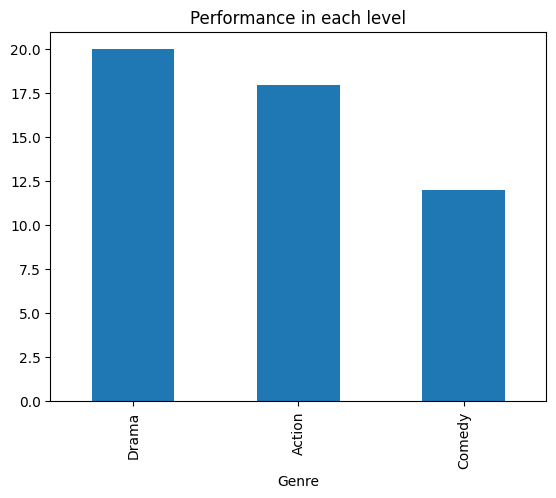

In [ ]:
res = df['Genre'].value_counts()
res.plot(kind= 'bar', title = 'Performance in each level')

<Axes: ylabel='Frequency'>

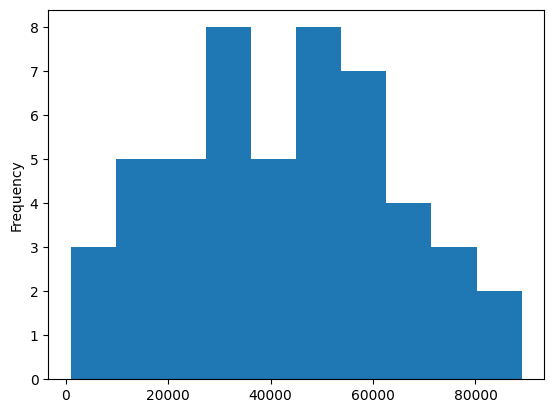

In [ ]:
df = orginal_vtable
res= df['Income']
res.plot(kind='hist')


<Axes: title={'center': 'abc'}, ylabel='count'>

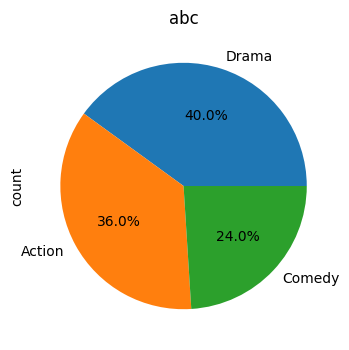

In [ ]:
res = df['Genre'].value_counts()
res.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='abc',
    figsize=(6, 4)
)

lab08 by patel jatin


array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

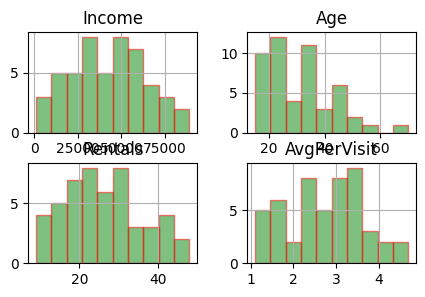

In [ ]:
print('lab08 by patel jatin')
df = orginal_vtable
res = df[['Income', 'Age', 'Rentals', 'AvgPerVisit']]

res.hist(alpha=0.5,edgecolor='red', color = 'green', figsize=(5, 3))



<Axes: xlabel='Like'>

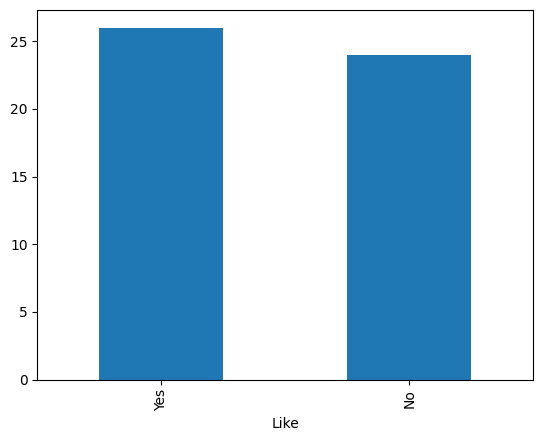

In [ ]:
res = df['Like'].value_counts()
res.plot(kind= 'bar')

#step3: Convert Categorical data


# Method 1 : Using LabelEncoder

In [ ]:
df = orginal_vtable
print(df.shape)
df.head(2)

(50, 8)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


In [ ]:
# Need Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 1 : Using LabelEncoder
# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features


df = orginal_vtable
from sklearn.preprocessing import LabelEncoder

# All category feature need to transfer to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
#print(df.dtypes)
df.head(2)

# vs Method


print(df.dtypes)
df.head(2)

Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,0,1,19,8,20,10,0,1
1,1,0,24,13,2,18,2,0


In [ ]:
# vs method
le = LabelEncoder()
df = orginal_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])
df_use_LabelEncoder = df
print(df.dtypes)
df.head(2)


Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000.0,25,32,2.5,0,1
1,2,0,54000.0,33,12,3.4,2,0


# step 4: KNN Classfication

In [ ]:
# Current process data has not category
vtable_afterLabelEncoder = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,1,45000.0,25,32,2.5,0
1,0,54000.0,33,12,3.4,2
2,0,32000.0,20,42,1.6,1


In [ ]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 9
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 6)
(10, 6)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=9, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.33      1.00      0.50         3

    accuracy                           0.40        10
   macro avg       0.67      0.57      0.38        10
weighted avg       0.80      0.40      0.33        10

------ Confusion Matrix
[[1 6]
 [0 3]]


#step5 : Coverting Categorical




## Method 2 : Using get_dummies -

In [ ]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies

gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object
   Cust ID  Gender   Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1  45000.0   25       32          2.5      0     1
1        2       0  54000.0   33       12          3.4      2     0
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1   45000   25       32            2      0     1
1        2       0   54000   33       12            3      2     0


In [ ]:

# Convert categorical features to numerical using get_dummies

df = orginal_vtable
category_cols = ['Gender', 'Genre', 'Like']

df_use_dummies = pd.get_dummies(df, columns=category_cols, dtype=int)
print(df_use_dummies.shape)
df_use_dummies.head(3)


(50, 12)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2,Like_0,Like_1
0,1,45000.0,25,32,2.5,0,1,1,0,0,0,1
1,2,54000.0,33,12,3.4,1,0,0,0,1,1,0
2,3,32000.0,20,42,1.6,1,0,0,1,0,1,0


# step 6: KNN


In [ ]:
# Separate data and target after dummies

all_cols = df_use_dummies.columns
print(all_cols)

size = len(all_cols)

# Drop last column (target) and one dummy column (last genre)
data_cols = all_cols[0:(size-2)]
print(data_cols)

# Features (X)
v_data = df_use_dummies[data_cols]

# Target (y)
v_target = df_use_dummies[all_cols[size-1]]

# Output
print(v_data.shape)
print(v_target.shape)

Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_0',
       'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2', 'Like_0', 'Like_1'],
      dtype='object')
Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_0',
       'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2'],
      dtype='object')
(50, 10)
(50,)


In [ ]:
v_data.head(2)

,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2
0,1,45000.0,25,32,2.5,0,1,1,0,0
1,2,54000.0,33,12,3.4,1,0,0,0,1


In [ ]:
print(v_data.shape)   # (50, 7)
print(v_target.shape) # (50,)

(50, 10)
(50,)


In [ ]:
data_train.describe()

,Gender,Income,Age,Rentals,AvgPerVisit,Genre
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.525000,42075.000000,31.800000,26.725000,2.812500,1.025000
std,0.505736,20391.536077,12.002564,9.771721,0.867708,0.919518
min,0.000000,1000.000000,16.000000,11.000000,1.400000,0.000000
25%,0.000000,25750.000000,23.500000,19.000000,2.200000,0.000000
50%,1.000000,43000.000000,30.000000,25.500000,2.850000,1.000000
75%,1.000000,56000.000000,35.250000,32.250000,3.325000,2.000000
max,1.000000,83000.000000,70.000000,48.000000,4.700000,2.000000


In [ ]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    v_data, v_target, random_state=11, test_size=0.2
)

print(data_train.shape)
print(data_test.shape)
print(target_train.shape)
print(target_test.shape)

# Step 4: Scale data (IMPORTANT for KNN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_test = scaler.transform(data_test)

# Step 5: Create KNN classifier
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=3, weights='distance')
print(knn_classifier)

# Train
knn_classifier.fit(data_train, target_train)

# Step 6: Predict
predicted = knn_classifier.predict(data_test)

# Step 7: Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(target_test, predicted))

print('------ Confusion Matrix')
print(confusion_matrix(target_test, predicted))

(40, 10)
(10, 10)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.50      0.67      0.57         3

    accuracy                           0.70        10
   macro avg       0.67      0.69      0.67        10
weighted avg       0.73      0.70      0.71        10

------ Confusion Matrix
[[5 2]
 [1 2]]


# LAB 09 using decision tree

# Convert categoric feature to numerical feature




## Method 1 : Using HotOneEncoder

In [ ]:
# use score method (correct variables)

score = knn_classifier.score(data_test, target_test)
print(score)

0.7


In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

[[5 2]
 [1 2]]


In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.50      0.67      0.57         3

    accuracy                           0.70        10
   macro avg       0.67      0.69      0.67        10
weighted avg       0.73      0.70      0.71        10

